# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Grady Berlik

**Date:** 9/2/2026

In [7]:
# Your Phase 1 solution to the problem goes here.
import pandas as pd
import numpy as np
url = "/content/airbnb_hw.csv"
df = pd.read_csv(url)
print(df['Price'].dtype)
# obj not number
print(df['Price'].isna().sum())
# 0 missing rn
print(df['Price'].astype(str).unique()[:100])
# no $ but commas in the big numbers, need to fix that
df['Price'] = df['Price'].str.replace(',', '', regex=False)
# strip commas
df['Price'] = df['Price'].astype(int)
print(df.info())
# int64 now
print(df['Price'].isna().sum())
# recheck missing
'''
For the Price column, I noticed it was being read in as an object instead of a number.
When I looked closer I saw that any price over 999 has a comma in it like "1,000" instead of "1000", and pandas reads that as a string instead of a number.
There weren't any dollar signs in this dataset. I replaced the commas with nothing using .str.replace() and then converted the column to int.
I checked for missing values before and after and it was 0 both times, so the only issue was the comma formatting, nothing was actually missing.
'''


object
0
['145' '37' '28' '199' '549' '149' '250' '90' '270' '290' '170' '59' '49'
 '68' '285' '75' '100' '150' '700' '125' '175' '40' '89' '95' '99' '499'
 '120' '79' '110' '180' '143' '230' '350' '135' '85' '60' '70' '55' '44'
 '200' '165' '115' '74' '84' '129' '50' '185' '80' '190' '140' '45' '65'
 '225' '600' '109' '1,990' '73' '240' '72' '105' '155' '160' '42' '132'
 '117' '295' '280' '159' '107' '69' '239' '220' '399' '130' '375' '585'
 '275' '139' '260' '35' '133' '300' '289' '179' '98' '195' '29' '27' '39'
 '249' '192' '142' '169' '1,000' '131' '138' '113' '122' '329' '101']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30478 entries, 0 to 30477
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Host Id                     30478 non-null  int64  
 1   Host Since                  30475 non-null  object 
 2   Name                        30478 non-null  object 
 3   Neighbourho

'\nFor the Price column, I noticed it was being read in as an object instead of a number. \nWhen I looked closer I saw that any price over 999 has a comma in it like "1,200" instead of "1200", and pandas reads that as a string instead of a number. \nThere weren\'t any dollar signs in this dataset. I replaced the commas with nothing using .str.replace() and then converted the column to int. \nI checked for missing values before and after and it was 0 both times, so the only issue was the comma formatting, nothing was actually missing.\n'

In [15]:
# Your Phase 1 solution to the problem goes here.
import pandas as pd
import numpy as np
url = '/content/mn_police_use_of_force.csv'
df = pd.read_csv(url)
print(df['subject_injury'].isna().sum())
# num of na cell
total_cells = len(df['subject_injury'])
print(total_cells)
# total cells, na or not
pct_missing = df['subject_injury'].isna().mean() * 100
print(pct_missing)
# what % is actually missing.
df['subject_injury'] = df['subject_injury'].fillna('Unknown')
# not dropping these rows, just labeling as Unknown since we don't actually know if injury happened or not
print(df['subject_injury'].value_counts())
cross_tab = pd.crosstab(df['force_type'], df['subject_injury'])
print(cross_tab)


'''
About 76% of the subject_injury values are missing, so 3 out of every 4 rows don't have this info.
That's a concern because if I wanted to say something like "X% of people were injured" that number would only be based on the 24% of rows that actually have data, so it might not show the real picture.
Instead of dropping the missing rows, I recoded them as "Unknown" so I could keep all the rows and actually see where the missingness is coming from.
When I crosstabbed force_type against subject_injury (including Unknown), the Unknown values aren't spread out evenly.
Maximal Restraint Technique and Less Lethal are Unknown 100% of the time, and Chemical Irritant is about 89% Unknown.
But Gun Point Display is only Unknown 26% of the time and Firearm is 0%.
So whether injury gets recorded seems to depend on what type of force was used; I don't think it would be random.
'''


9848
12925
76.19342359767892
subject_injury
Unknown    9848
Yes        1631
No         1446
Name: count, dtype: int64
subject_injury                 No  Unknown   Yes
force_type                                      
Baton                           0        2     2
Bodily Force                 1093     7051  1286
Chemical Irritant             131     1421    41
Firearm                         2        0     0
Gun Point Display              33       27    44
Improvised Weapon              34       74    40
Less Lethal                     0       87     0
Less Lethal Projectile          1        0     2
Maximal Restraint Technique     0      170     0
Police K9 Bite                  2       31    44
Taser                         150      985   172


'\nAbout 76% of the subject_injury values are missing, so 3 out of every 4 rows don\'t have this info. \nThat\'s a concern because if I wanted to say something like "X% of people were injured" that number would only be based on the 24% of rows that actually have data, so it might not show the real picture. \nInstead of dropping the missing rows, I recoded them as "Unknown" so I could keep all the rows and actually see where the missingness is coming from.\nWhen I crosstabbed force_type against subject_injury (including Unknown), the Unknown values aren\'t spread out evenly. \nMaximal Restraint Technique and Less Lethal are Unknown 100% of the time, and Chemical Irritant is about 89% Unknown. \nBut Gun Point Display is only Unknown 26% of the time and Firearm is 0%. \nSo whether injury gets recorded seems to depend on what type of force was used; I don\'t think it would be random.\n'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7117 entries, 0 to 7116
Data columns (total 23 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            7117 non-null   object 
 1   Year            7115 non-null   float64
 2   Type            7099 non-null   object 
 3   Country         7067 non-null   object 
 4   State           6630 non-null   object 
 5   Location        6550 non-null   object 
 6   Activity        6534 non-null   object 
 7   Name            6899 non-null   object 
 8   Sex             6539 non-null   object 
 9   Age             4123 non-null   object 
 10  Injury          7081 non-null   object 
 11  Fatal Y/N       6556 non-null   object 
 12  Time            3590 non-null   object 
 13  Species         3986 non-null   object 
 14  Source          7097 non-null   object 
 15  pdf             6799 non-null   object 
 16  href formula    6794 non-null   object 
 17  href            6796 non-null   o

/tmp/ipykernel_456/3318618726.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_age['Age'] = df_age['Age'].astype(int)


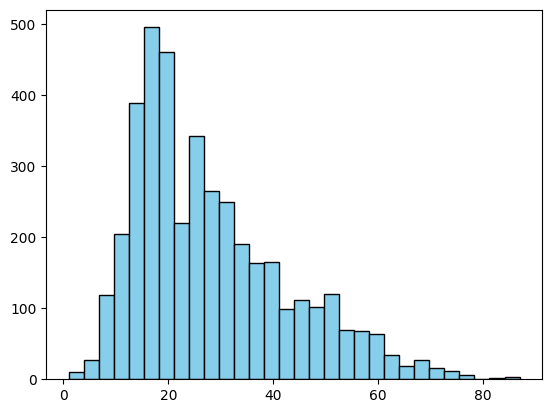

0.8747128197273702
0.7395643007730147


In [16]:
import pandas as pd
df = pd.read_excel('/content/GSAF5.xls')
df.info()
df.head(5)
# checking which cols actually have data instead of just guessing by position
print(df.isna().sum())
# Unnamed: 21 and Unnamed: 22 are basically empty (only 1-2 random notes like "stopped here")
# the rest of the last few cols (pdf, href, case number etc) actually have data so keeping those.
df = df.drop(columns=['Unnamed: 21', 'Unnamed: 22'])
print(df.shape)
print(df['Year'].isna().sum())
df = df.dropna(subset=['Year'])
# getting rid of rows with no year at all
print(df['Year'].describe())
# min is 0 which makes no sense, some of these year values are just garbage (0, 5, 77 etc)
df_filtered = df[df['Year'] >= 1940]
print(df_filtered['Year'].describe())
# only keeping attacks from 1940 onward like the question asks
import matplotlib.pyplot as plt
#this lets me make the histogram
attacks_per_year = df_filtered.groupby('Year').size()
print(attacks_per_year)
# looks like attacks go up over time overall

df['Age'] = df['Age'].astype(str).str.extract(r'(\d+)').astype(float)
df_age = df.dropna(subset=['Age'])
df_age['Age'] = df_age['Age'].astype(int)
# pulling out just the number since some entries were words/symbols mixed in
plt.hist(df_age['Age'], bins=30, color='skyblue', edgecolor='black')
plt.show()
df['Sex_clean'] = df['Sex'].astype(str).str.strip().str.upper()
df['Sex_clean'] = df['Sex_clean'].where(df['Sex_clean'].isin(['M', 'F']))
# anything not M or F becomes NaN so it doesn't mess up the %
print((df['Sex_clean'] == 'M').sum() / df['Sex_clean'].notna().sum())
df['Type'] = df['Type'].str.strip().str.title()
df['Type'] = df['Type'].where(df['Type'].isin(['Provoked', 'Unprovoked']), 'Unknown')
# collapsing into 3 categories, stuff like Invalid/Watercraft/Sea Disaster/Boat all become Unknown too

prop_unprovoked = (df['Type'] == 'Unprovoked').mean()
print(prop_unprovoked)













After dropping rows with no year, the minimum was 0, plus a few other clearly wrong tiny values like 5 and 77. There were also some old but real years in the 1500-1600s from historical attacks. I filtered to 1940 as asked. From 1940 on, attacks are generally increasing over time, especially in more recent decades.I cleaned up capitalization first (like " Provoked" or "UNprovoked"), then grouped everything else that wasn't Provoked or Unprovoked (Invalid, watercraft, Sea Disaster, Boat, Questionable, and true missing values) into Unknown. After cleaning, about 74% of attacks are Unprovoked. After extracting the numeric part of Age and dropping rows where no number could be found, I ended up with 4,051 valid ages out of the original dataset. The ages range from about 1 to 87, with most victims in their late teens to 30s. About 87% of victims are male. Based on the cleaned Sex_clean column (excluding entries that weren't clearly M or F).

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 18ac3056a64dbe0f1b5dc28564111e585f7243d4
- **AI tool and model used:** Gemini 3.8 Flash

### *Prompts used

1. Review my Phase 1 code below. Provide:
1. A concise, numbered list of specific improvements (performance, edge cases, best practices).
2. The complete, updated Phase 2 code with those improvements applied.


### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Eliminate redundant duplicate code: Remove the identical block of Airbnb data
loading and price inspection executed twice at the beginning of the script.

2. Robust numeric conversion with error handling: Replace direct astype(int) casting on Price with pd.to_numeric(..., errors='coerce') to prevent script crashes if unexpected non-numeric characters or missing values exist.

3. Fix SettingWithCopyWarning in Age filtering: Avoid direct assignment on a slice (df_age['Age'] = df_age['Age'].astype(int)) by using .copy() or chaining the transformation directly to prevent Pandas mutation warnings.

4. Resolve DataFrame reference discrepancy: The histogram and subsequent demographic transformations operate on the unfiltered df rather than the filtered subset df_filtered (attacks from 1940 onward). Align the data pipelines consistently.


### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | Accept, I accidentally copied my first chunk of code and accidentally replaced my answer to Q1 part 2|

---


| 2 | Accept / modify / reject | Accept: It would be a lot safer so it doesn't crash |
| 3 | Accept / modify / reject | Accept: Minor detail but technically better and cleaner |
| 4 | Accept / modify / reject | Reject: I don't think this is necessary to the assignment |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

object
0
['145' '37' '28' '199' '549' '149' '250' '90' '270' '290' '170' '59' '49'
 '68' '285' '75' '100' '150' '700' '125' '175' '40' '89' '95' '99' '499'
 '120' '79' '110' '180']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30478 entries, 0 to 30477
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Host Id                     30478 non-null  int64  
 1   Host Since                  30475 non-null  object 
 2   Name                        30478 non-null  object 
 3   Neighbourhood               30478 non-null  object 
 4   Property Type               30475 non-null  object 
 5   Review Scores Rating (bin)  22155 non-null  float64
 6   Room Type                   30478 non-null  object 
 7   Zipcode                     30344 non-null  float64
 8   Beds                        30393 non-null  float64
 9   Number of Records           30478 non-null  int64  
 10  Number Of Reviews    

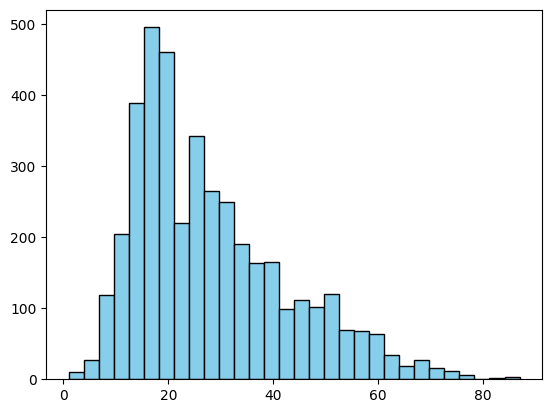

0.8747128197273702
0.7395643007730147


In [17]:
# Your Phase 2 solution to the problem goes here.
import pandas as pd
import numpy as np
url = "/content/airbnb_hw.csv"
df = pd.read_csv(url)
print(df['Price'].dtype)
# obj not number
print(df['Price'].isna().sum())
# 0 missing rn
print(df['Price'].astype(str).unique()[:30])
# no $ but commas in the big numbers, need to fix that
df['Price'] = df['Price'].str.replace(',', '', regex=False)
# strip commas
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
# using to_numeric with coerce instead of astype(int) so it doesn't crash if theres a weird value in there, just turns it into NaN instead
print(df.info())
print(df['Price'].isna().sum())
# recheck missing after cleaning
import pandas as pd
df = pd.read_excel('/content/GSAF5.xls')
df.info()
df.head(5)
# checking which cols actually have data instead of just guessing by position
print(df.isna().sum())

# Unnamed: 21 and Unnamed: 22 are basically empty (only 1-2 random notes like "stopped here")
# the rest of the last few cols (pdf, href, case number etc) actually have data so keeping those
df = df.drop(columns=['Unnamed: 21', 'Unnamed: 22'])
print(df.shape)

print(df['Year'].isna().sum())
df = df.dropna(subset=['Year'])
# getting rid of rows with no year at all
print(df['Year'].describe())
# min is 0 which makes no sense, some of these year values are just garbage (0, 5, 77 etc)

df_filtered = df[df['Year'] >= 1940]
print(df_filtered['Year'].describe())
# only keeping attacks from 1940 onward like the question asks

import matplotlib.pyplot as plt

attacks_per_year = df_filtered.groupby('Year').size()
print(attacks_per_year)
# looks like attacks go up over time overall

df['Age'] = df['Age'].astype(str).str.extract(r'(\d+)').astype(float)
df_age = df.dropna(subset=['Age']).copy()
# added .copy() here so pandas doesn't throw a SettingWithCopyWarning on the next line
df_age['Age'] = df_age['Age'].astype(int)
# pulling out just the number since some entries were words/symbols mixed in

plt.hist(df_age['Age'], bins=30, color='skyblue', edgecolor='black')
plt.show()

df['Sex_clean'] = df['Sex'].astype(str).str.strip().str.upper()
df['Sex_clean'] = df['Sex_clean'].where(df['Sex_clean'].isin(['M', 'F']))
# anything not M or F becomes NaN so it doesn't mess up the %
print((df['Sex_clean'] == 'M').sum() / df['Sex_clean'].notna().sum())

df['Type'] = df['Type'].str.strip().str.title()
df['Type'] = df['Type'].where(df['Type'].isin(['Provoked', 'Unprovoked']), 'Unknown')
# collapsing into 3 categories, stuff like Invalid/Watercraft/Sea Disaster/Boat all become Unknown too
prop_unprovoked = (df['Type'] == 'Unprovoked').mean()
print(prop_unprovoked)

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]
AI is very good at finding small syntax or safety errors in code. I would have never discovered such minute details in my code, and I honestly wouldn't have even bothered to look since the code already works. However, Gemini is able to identify the "optimal" and safest way to get the job done, which contrasts the sloppier but still technically correct way that I did it. It really has few limitations at this level. My one rejected comment was still a good suggestion, I just didn't think that the directions clarified whether that step was necessary. I manually verified it's suggestions, and they all appear to be correct. In the future, I will definitely be using AI to double check for small syntax errors and any code I may have left that could crash the terminal or something like that. Additionally, since I manually approved each suggestion, it's hard to have any serious concerns since AI doesn't have access to directly editing my file.